# EDA: Reddit Submissions (Arctic Shift archive)

Exploratory analysis of [`open-index/arctic`](https://huggingface.co/datasets/open-index/arctic), a Parquet copy of
the Arctic Shift Reddit dumps (2005-12 to 2026-02, ~2.8B submissions, ~12.9B comments, 1.3 TB).

The project predicts **post success**, so this notebook focuses on **submissions**. Downloading the full archive
is not practical. The notebook samples shards from every month of **2025** instead.

**Excluded from all analysis** (except the data quality checks in section 3):
- NSFW posts (`over_18 = true`).
- Deleted or removed posts (`author = '[deleted]'`, or `selftext` is `[deleted]` or `[removed]`, or the title is a
  deletion marker). Reddit clears the author, body, and URL of these posts, so their content and post type are unknown.

**Sampling note:** the shards in a month are in time order. One shard of 500k rows covers only ~10 hours.
The notebook takes shards spread evenly across each month, so that every month, day of the week, and hour
are in the sample. Each month gets the same number of shards, so **post counts per month, day, or hour in this
sample do not show real Reddit activity**. Rates (for example, the share of posts with score ≥ 10) are valid.

Summary tables are computed in DuckDB on all sampled posts. Plots that need individual posts in pandas use
a fixed random sample of 2M posts (`subs_sample`).

In [1]:
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from huggingface_hub import HfApi, snapshot_download

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.3f}".format)

# Chart style: thin marks, recessive grid, one blue for single-series charts
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.color": "#e4e3df",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA]),
})

/private/tmp/claude-501/-Users-znorton-git-reddit-post-predictor/b748d9c0-e375-4234-9d23-e809649a4ec6/scratchpad/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration and download

In [2]:
REPO = "open-index/arctic"
YEAR = 2025               # any full year from 2006 to 2025
MONTHS = range(1, 13)
SHARDS_PER_MONTH = 12     # ~70 MB and 500k rows (~10 hours of posts) per shard; None = all shards
PANDAS_SAMPLE_ROWS = 2_000_000
DATA_DIR = Path("data/arctic")

api = HfApi()
shards = []
for m in MONTHS:
    month_shards = sorted(
        f.path for f in api.list_repo_tree(REPO, path_in_repo=f"data/submissions/{YEAR}/{m:02d}", repo_type="dataset")
        if f.path.endswith(".parquet")
    )
    n = len(month_shards) if SHARDS_PER_MONTH is None else min(SHARDS_PER_MONTH, len(month_shards))
    # Take shards spread evenly across the month (shards are in time order)
    idx = np.unique(np.linspace(0, len(month_shards) - 1, n).round().astype(int))
    shards += [month_shards[i] for i in idx]
    print(f"{YEAR}/{m:02d}: using {len(idx)} of {len(month_shards)} shards")
print(f"Total: {len(shards)} shards")

2025/01: using 12 of 80 shards
2025/02: using 12 of 73 shards
2025/03: using 12 of 80 shards


2025/04: using 12 of 78 shards
2025/05: using 12 of 82 shards


2025/06: using 12 of 81 shards
2025/07: using 12 of 86 shards
2025/08: using 12 of 89 shards


2025/09: using 12 of 85 shards
2025/10: using 12 of 88 shards
2025/11: using 12 of 86 shards


2025/12: using 12 of 86 shards
Total: 144 shards


In [3]:
# Files that are already in DATA_DIR are not downloaded again
snapshot_download(REPO, repo_type="dataset", local_dir=DATA_DIR, allow_patterns=shards, max_workers=8)
local_files = [str(DATA_DIR / s) for s in shards]
con = duckdb.connect()
file_list = ", ".join(f"'{f}'" for f in local_files)
con.execute(f"CREATE OR REPLACE VIEW raw_subs AS SELECT * FROM read_parquet([{file_list}])")
q = lambda sql: con.execute(sql).df()

# Exclusion rules. All analysis after section 3 uses the `subs` view, which drops these posts.
NSFW_SQL = "coalesce(over_18, false)"
DELETED_SQL = """(
    author = '[deleted]'
    OR coalesce(selftext, '') IN ('[deleted]', '[removed]')
    OR title IN ('[deleted by user]', '[ Removed by moderator ]')
)"""
con.execute(f"CREATE OR REPLACE VIEW subs AS SELECT * FROM raw_subs WHERE NOT {NSFW_SQL} AND NOT {DELETED_SQL}")

q(f"""
SELECT count(*)                                              AS raw_posts,
       count(*) FILTER ({NSFW_SQL})                          AS nsfw,
       count(*) FILTER (NOT {NSFW_SQL} AND {DELETED_SQL})    AS sfw_but_deleted_or_removed,
       count(*) FILTER (NOT {NSFW_SQL} AND NOT {DELETED_SQL}) AS posts_kept,
       posts_kept / raw_posts                                AS kept_fraction
FROM raw_subs
""").T.rename(columns={0: "value"})


Fetching 144 files:   0%|          | 0/144 [00:00<?, ?it/s]


Fetching 144 files: 100%|██████████| 144/144 [00:00<00:00, 2132.10it/s]

,value
raw_posts,"69,261,822.000"
nsfw,"29,444,333.000"
sfw_but_deleted_or_removed,"4,227,885.000"
posts_kept,"35,589,604.000"
kept_fraction,0.514


In [4]:
# Fixed random sample for plots that need individual posts in pandas
con.execute(f"CREATE OR REPLACE TABLE subs_sample AS "
            f"SELECT * FROM subs USING SAMPLE reservoir({PANDAS_SAMPLE_ROWS} ROWS) REPEATABLE (42)")
print(f"subs_sample: {con.execute('SELECT count(*) FROM subs_sample').fetchone()[0]:,} posts")

subs_sample: 2,000,000 posts


## 2. Schema and overview

In [5]:
q("DESCRIBE subs")

,column_name,column_type,null,key,default,extra
0,id,VARCHAR,YES,None,None,None
1,author,VARCHAR,YES,None,None,None
2,subreddit,VARCHAR,YES,None,None,None
3,title,VARCHAR,YES,None,None,None
4,selftext,VARCHAR,YES,None,None,None
5,score,BIGINT,YES,None,None,None
6,created_utc,BIGINT,YES,None,None,None
7,created_at,TIMESTAMP,YES,None,None,None
8,title_length,BIGINT,YES,None,None,None
9,num_comments,BIGINT,YES,None,None,None


In [6]:
q("""
SELECT count(*)                    AS n_posts,
       count(DISTINCT id)          AS n_unique_ids,
       count(DISTINCT subreddit)   AS n_subreddits,
       count(DISTINCT author)      AS n_authors,
       min(created_at)             AS first_post,
       max(created_at)             AS last_post
FROM subs
""").T

,0
n_posts,35589604
n_unique_ids,35589604
n_subreddits,842838
n_authors,11201292
first_post,2025-01-01 00:00:00
last_post,2025-12-31 23:59:59


In [7]:
q("SELECT * FROM subs USING SAMPLE 5 ROWS")

,id,author,subreddit,title,selftext,score,created_utc,created_at,title_length,num_comments,url,over_18,link_flair_text,author_flair_text
0,1hqzyx0,Weak_Advantage_8560,cats,My car diagnosed as kidney failure 😞,\n\nMy 5 years old cat diagnosed as kidney failure at 3rd stage. Actually ev...,5,1735725172,2025-01-01 09:52:52,37,1,https://www.reddit.com/r/cats/comments/1hqzyx0/my_car_diagnosed_as_kidney_fa...,False,Medical Questions,NaN
1,1hr000p,rattist,HonkaiStarRail,The Playable characters' social media usernames (From photo event),,3015,1735725319,2025-01-01 09:55:19,66,131,https://www.reddit.com/gallery/1hr000p,False,Meme / Fluff,:Boothill:
2,1hr05ol,OldMatter4437,carporn,[2048x1536] This is a Beaumont SD coupe 1969 How do you Americans think abou...,,1,1735726024,2025-01-01 10:07:04,110,1,https://i.redd.it/lpn16u9kwcae1.jpeg,False,NaN,NaN
3,1hr06p1,GeotheHSLord,Monstercat,(2025) 1/1 Monstercat Release Birthdays!,"Today is January 1st, 2025. Happy New Year Monstercat Fam and Happy Birthday...",22,1735726154,2025-01-01 10:09:14,40,6,https://www.reddit.com/r/Monstercat/comments/1hr06p1/2025_11_monstercat_rele...,False,NaN,Teddy Killerz:teddykillerz:
4,1hr07q2,K-A-S-GAMES,DDLC,New Friend 11#🍪,"Bun is in another castle, under heavy protection.",257,1735726300,2025-01-01 10:11:40,15,34,https://i.redd.it/24znbarfxcae1.jpeg,False,Fun,:sayori-v: bun enjoyer :sayori-line6:


## 3. Data quality (SFW posts, before the deleted/removed filter)

This section uses `raw_subs` to show what the filter removes. Reddit uses the markers `[deleted]` and `[removed]`
for removed content. A deleted post keeps its title and score, but loses its author, body, and URL.

In [8]:
cols = [r[0] for r in con.execute("DESCRIBE raw_subs").fetchall()]
nulls = q("SELECT " + ", ".join(f"avg(({c} IS NULL)::INT) AS \"{c}\"" for c in cols)
          + f" FROM raw_subs WHERE NOT {NSFW_SQL}").T
nulls.columns = ["null_fraction"]
nulls.sort_values("null_fraction", ascending=False)

,null_fraction
author_flair_text,0.897
link_flair_text,0.465
id,0.000
author,0.000
subreddit,0.000
title,0.000
selftext,0.000
score,0.000
created_utc,0.000
created_at,0.000


In [9]:
q(f"""
SELECT avg((author = '[deleted]')::INT)                AS author_deleted,
       avg((selftext = '[deleted]')::INT)              AS selftext_deleted,
       avg((selftext = '[removed]')::INT)              AS selftext_removed,
       avg((title = '[deleted by user]')::INT)         AS title_deleted_by_user,
       avg((title = '[ Removed by moderator ]')::INT)  AS title_removed_by_moderator,
       avg((coalesce(url, '') = '')::INT)              AS url_empty,
       avg({DELETED_SQL}::INT)                         AS any_deleted_or_removed
FROM raw_subs WHERE NOT {NSFW_SQL}
""").T.rename(columns={0: "fraction"})

,fraction
author_deleted,0.008
selftext_deleted,0.005
selftext_removed,0.100
title_deleted_by_user,0.000
title_removed_by_moderator,0.002
url_empty,0.008
any_deleted_or_removed,0.106


In [10]:
# Posts with no URL are almost all deleted posts, so the filter removes them too
q(f"""
SELECT {DELETED_SQL} AS deleted_or_removed, count(*) AS posts_with_empty_url
FROM raw_subs WHERE NOT {NSFW_SQL} AND coalesce(url, '') = ''
GROUP BY 1
""")

,deleted_or_removed,posts_with_empty_url
0,False,7
1,True,299938


## 4. Target variables: `score` and `num_comments`

Both are candidate measures of "success". The values are captured at **archival time**.
Arctic Shift collects posts soon after they are created, so the values for some posts are
lower than their final values. Keep this in mind when you define the label.

In [11]:
q("""
SELECT 'score' AS metric, min(score) AS min, quantile_cont(score, [0.25, 0.5, 0.75, 0.9, 0.99, 0.999]) AS quantiles,
       avg(score) AS mean, max(score) AS max FROM subs
UNION ALL
SELECT 'num_comments', min(num_comments), quantile_cont(num_comments, [0.25, 0.5, 0.75, 0.9, 0.99, 0.999]),
       avg(num_comments), max(num_comments) FROM subs
""")

,metric,min,quantiles,mean,max
0,score,0,"[1.0, 2.0, 11.0, 65.0, 970.0, 6650.0]",62.610,242068
1,num_comments,0,"[0.0, 2.0, 7.0, 22.0, 135.0, 603.0]",10.922,52946


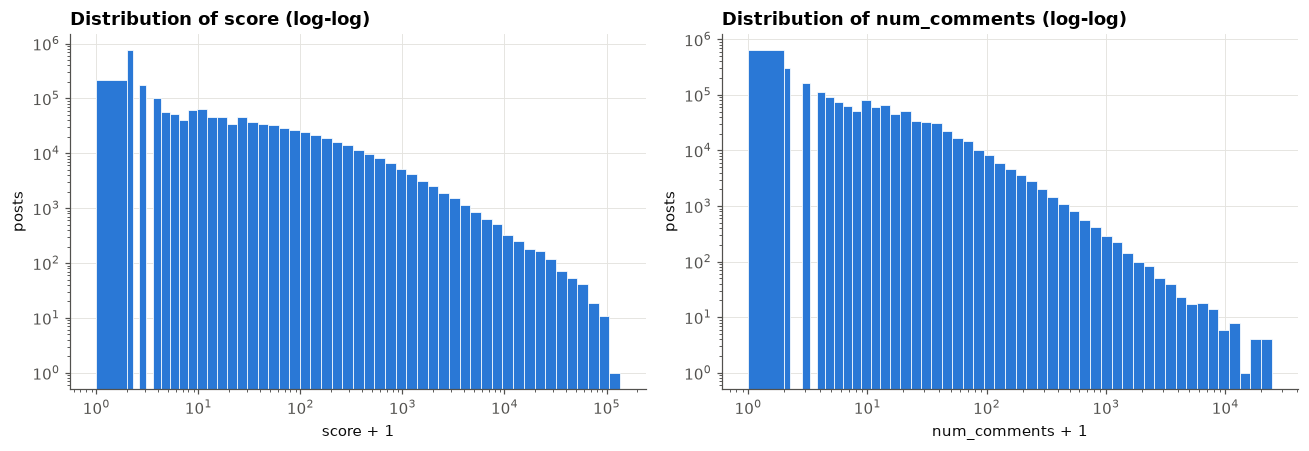

In [12]:
s = q("SELECT score, num_comments FROM subs_sample")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col in zip(axes, ["score", "num_comments"]):
    v = s[col].clip(lower=0)
    bins = np.unique(np.concatenate([[0], np.logspace(0, np.log10(v.max() + 1), 50)]))
    ax.hist(v + 1, bins=bins + 1, color=BLUE, edgecolor="white", linewidth=0.5)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(f"Distribution of {col} (log-log)")
    ax.set_xlabel(f"{col} + 1"); ax.set_ylabel("posts")
plt.tight_layout()

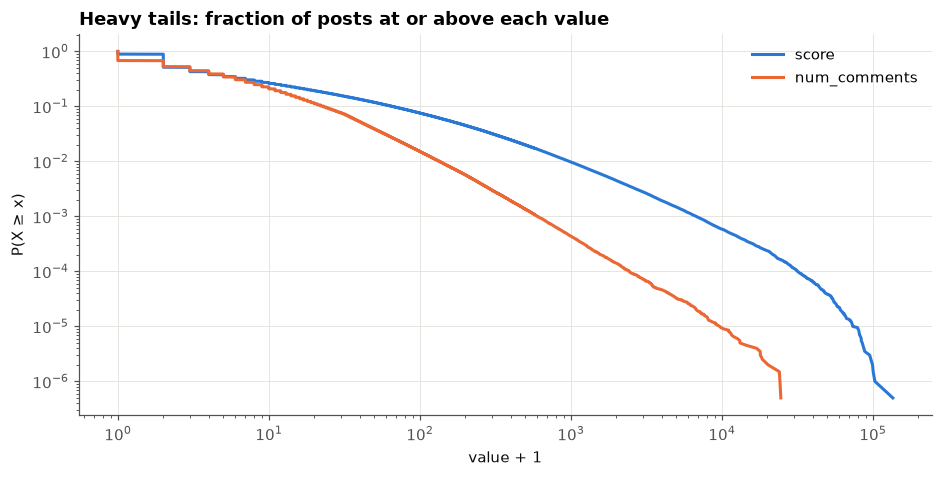

In [13]:
# Complementary CDF: fraction of posts with a value of at least x
fig, ax = plt.subplots()
for col, color in [("score", BLUE), ("num_comments", ORANGE)]:
    v = np.sort(s[col].clip(lower=0).to_numpy())
    ccdf = 1 - np.arange(len(v)) / len(v)
    ax.plot(v + 1, ccdf, color=color, linewidth=2, label=col)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("value + 1"); ax.set_ylabel("P(X ≥ x)")
ax.set_title("Heavy tails: fraction of posts at or above each value")
ax.legend(frameon=False)

Spearman correlation (score, num_comments): 0.454


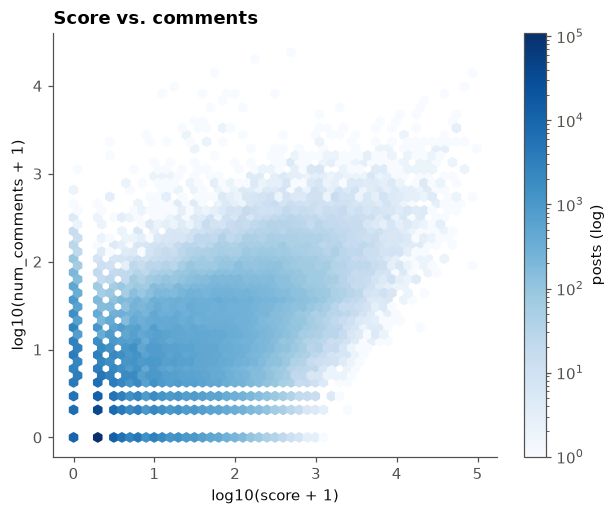

In [14]:
print("Spearman correlation (score, num_comments):",
      round(s[["score", "num_comments"]].corr(method="spearman").iloc[0, 1], 3))

hb = s.sample(min(len(s), 500_000), random_state=0)  # fewer points keep hexbin fast
fig, ax = plt.subplots(figsize=(6.5, 5))
h = ax.hexbin(np.log10(hb.score.clip(lower=0) + 1), np.log10(hb.num_comments + 1),
              gridsize=50, bins="log", cmap="Blues", mincnt=1)
fig.colorbar(h, ax=ax, label="posts (log)")
ax.set_xlabel("log10(score + 1)"); ax.set_ylabel("log10(num_comments + 1)")
ax.set_title("Score vs. comments"); ax.grid(False)
del s, hb

## 5. Subreddits

The baseline score is very different from one subreddit to the next. A score of 50 is a big success in a small
subreddit and a failure in r/pics. A per-subreddit normalization (for example, a percentile in the subreddit) is
probably necessary for the label.

In [15]:
sub_stats = q("""
SELECT subreddit,
       count(*)                              AS posts,
       median(score)                         AS median_score,
       quantile_cont(score, 0.9)             AS p90_score,
       avg(score)                            AS mean_score,
       median(num_comments)                  AS median_comments
FROM subs GROUP BY subreddit ORDER BY posts DESC
""")
print(f"{len(sub_stats):,} subreddits in sample")
sub_stats.head(25)

842,838 subreddits in sample


,subreddit,posts,median_score,p90_score,mean_score,median_comments
0,SwordAndSupperGame,371308,1.000,2.000,1.360,0.000
1,PokemonGoRaids,229926,1.000,1.000,1.057,1.000
2,AskReddit,219854,1.000,3.000,15.489,4.000
3,chessquiz,179129,1.000,1.000,1.033,1.000
4,automationContentCom,154783,1.000,1.000,0.999,0.000
5,Monopoly_GO,114703,1.000,2.000,2.186,3.000
6,AutoNewspaper,104107,1.000,1.000,1.011,0.000
7,Pixelary,90364,1.000,1.000,1.316,1.000
8,hatchcats,84609,1.000,1.000,1.047,1.000
9,opinionWarsDev,83523,1.000,1.000,1.000,0.000


top     10 subreddits -> 4.6% of posts
top    100 subreddits -> 11.1% of posts
top  1,000 subreddits -> 29.6% of posts
top 10,000 subreddits -> 68.3% of posts


Text(0.0, 1.0, 'Post volume concentration across subreddits')

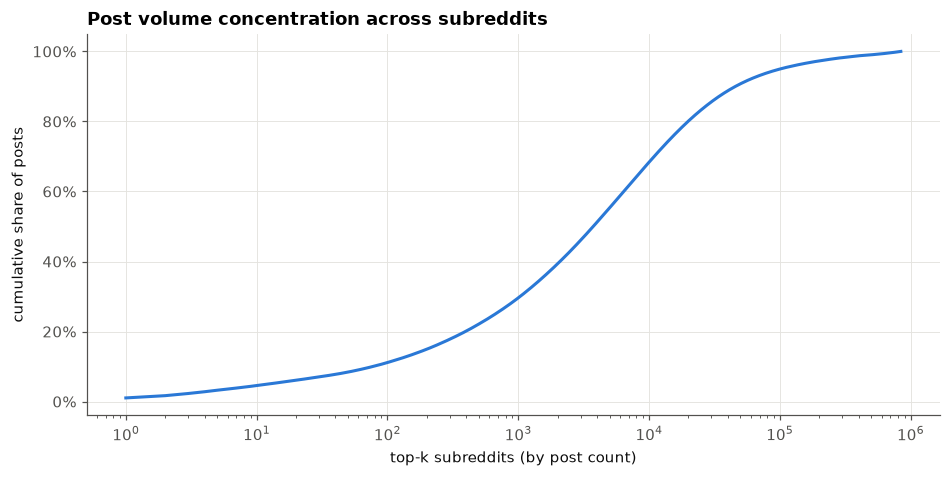

In [16]:
# Concentration: share of all posts that the top-k subreddits contain
cum = sub_stats.posts.cumsum() / sub_stats.posts.sum()
for k in [10, 100, 1_000, 10_000]:
    if k <= len(cum):
        print(f"top {k:>6,} subreddits -> {cum.iloc[k-1]:.1%} of posts")

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(cum) + 1), cum.values, color=BLUE, linewidth=2)
ax.set_xscale("log"); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("top-k subreddits (by post count)"); ax.set_ylabel("cumulative share of posts")
ax.set_title("Post volume concentration across subreddits")

Text(0.0, 1.0, 'Subreddit activity vs. 90th-percentile score')

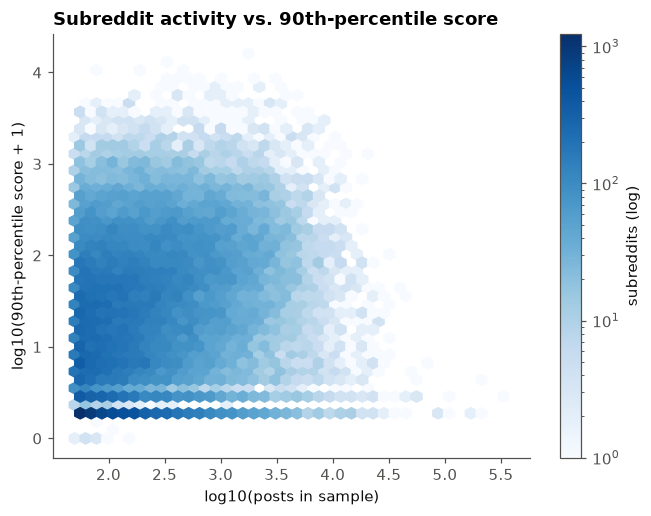

In [17]:
# Subreddit size vs. typical score (subreddits with >= 50 posts in the sample)
big = sub_stats[sub_stats.posts >= 50]
fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hexbin(np.log10(big.posts), np.log10(big.p90_score + 1), gridsize=40, bins="log", cmap="Blues", mincnt=1)
fig.colorbar(h, ax=ax, label="subreddits (log)")
ax.set_xlabel("log10(posts in sample)"); ax.set_ylabel("log10(90th-percentile score + 1)"); ax.grid(False)
ax.set_title("Subreddit activity vs. 90th-percentile score")

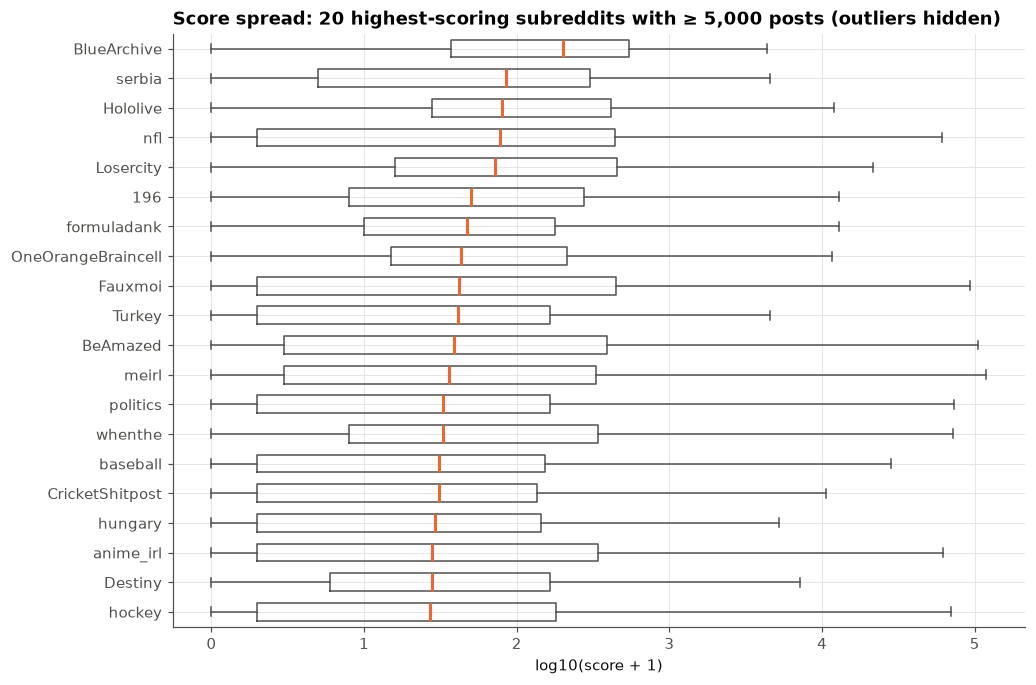

In [18]:
# The busiest subreddits are mostly bots/spam with score 1, so show the 20 active
# subreddits (>= 5,000 posts in the sample) with the highest median score instead
top20 = (sub_stats[sub_stats.posts >= 5_000]
         .sort_values(["median_score", "p90_score"], ascending=False).head(20).subreddit.tolist())
t = q(f"""
SELECT subreddit, score FROM subs
WHERE subreddit IN ({", ".join(f"'{x}'" for x in top20)})
""")
order = t.groupby("subreddit").score.median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot([np.log10(t.loc[t.subreddit == x, "score"].clip(lower=0) + 1) for x in order],
           orientation="horizontal", tick_labels=order, showfliers=False, widths=0.6,
           medianprops=dict(color=ORANGE, linewidth=2), boxprops=dict(color=MUTED),
           whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
ax.set_xlabel("log10(score + 1)")
ax.set_title("Score spread: 20 highest-scoring subreddits with ≥ 5,000 posts (outliers hidden)")
del t

## 6. Time of posting

All times are UTC. Each shard is one contiguous block of ~10 hours, so the sample has gaps.
The coverage chart shows which days of the year are in the sample.
**Post volume by month, day, or hour in this sample shows where the shards fall, not real Reddit activity.**
The rates (share of posts with score ≥ 10) are still valid in each group.

The scores were recorded at archival time. If posts were archived soon after they were created, late-year
months can show lower scores. The by-month chart checks this.

Text(0, 0.5, 'posts')

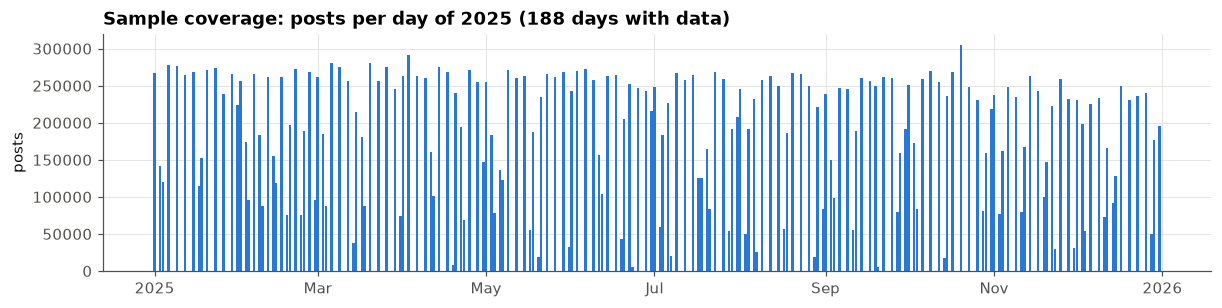

In [19]:
coverage = q("SELECT date_trunc('day', created_at) AS day, count(*) AS posts FROM subs GROUP BY 1 ORDER BY 1")
fig, ax = plt.subplots(figsize=(13, 2.8))
ax.bar(coverage.day, coverage.posts, width=0.9, color=BLUE)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.set_title(f"Sample coverage: posts per day of {YEAR} ({len(coverage)} days with data)"); ax.set_ylabel("posts")

,month,month_name,posts,median_score,p90_score,frac_score_ge_10,frac_comments_ge_10
0,1,January,3159227,2.000,70.000,0.266,0.214
1,2,February,3032657,2.000,67.000,0.262,0.208
2,3,March,3000704,2.000,72.000,0.271,0.215
3,4,April,3069169,2.000,68.000,0.267,0.208
4,5,May,2895062,2.000,69.000,0.272,0.218
5,6,June,3042704,2.000,69.000,0.268,0.216
6,7,July,3009237,2.000,67.000,0.268,0.217
7,8,August,2862983,2.000,59.000,0.252,0.202
8,9,September,2947866,2.000,63.000,0.257,0.204
9,10,October,3056473,1.000,54.000,0.237,0.185


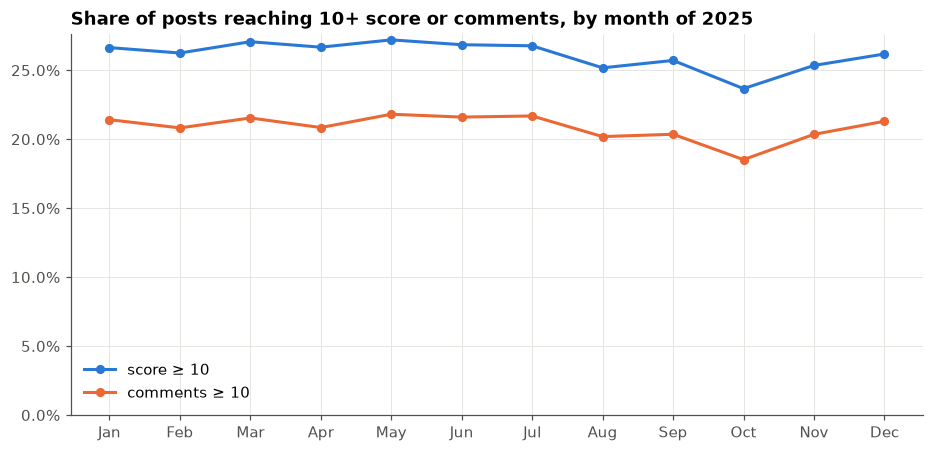

In [20]:
by_month = q("""
SELECT month(created_at) AS month, monthname(created_at) AS month_name, count(*) AS posts,
       median(score) AS median_score, quantile_cont(score, 0.9) AS p90_score,
       avg((score >= 10)::INT) AS frac_score_ge_10, avg((num_comments >= 10)::INT) AS frac_comments_ge_10
FROM subs GROUP BY 1, 2 ORDER BY 1
""")
fig, ax = plt.subplots()
ax.plot(by_month.month_name.str[:3], by_month.frac_score_ge_10, color=BLUE, linewidth=2, marker="o",
        markersize=5, label="score ≥ 10")
ax.plot(by_month.month_name.str[:3], by_month.frac_comments_ge_10, color=ORANGE, linewidth=2, marker="o",
        markersize=5, label="comments ≥ 10")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.set_ylim(bottom=0)
ax.set_title(f"Share of posts reaching 10+ score or comments, by month of {YEAR}")
ax.legend(frameon=False)
by_month

,dow,day,posts,median_score,frac_score_ge_10
0,1,Monday,5342215,2.000,0.256
1,2,Tuesday,4478454,2.000,0.258
2,3,Wednesday,6032102,2.000,0.257
3,4,Thursday,4918882,2.000,0.261
4,5,Friday,5475698,2.000,0.264
5,6,Saturday,4693069,2.000,0.264
6,7,Sunday,4649184,2.000,0.271


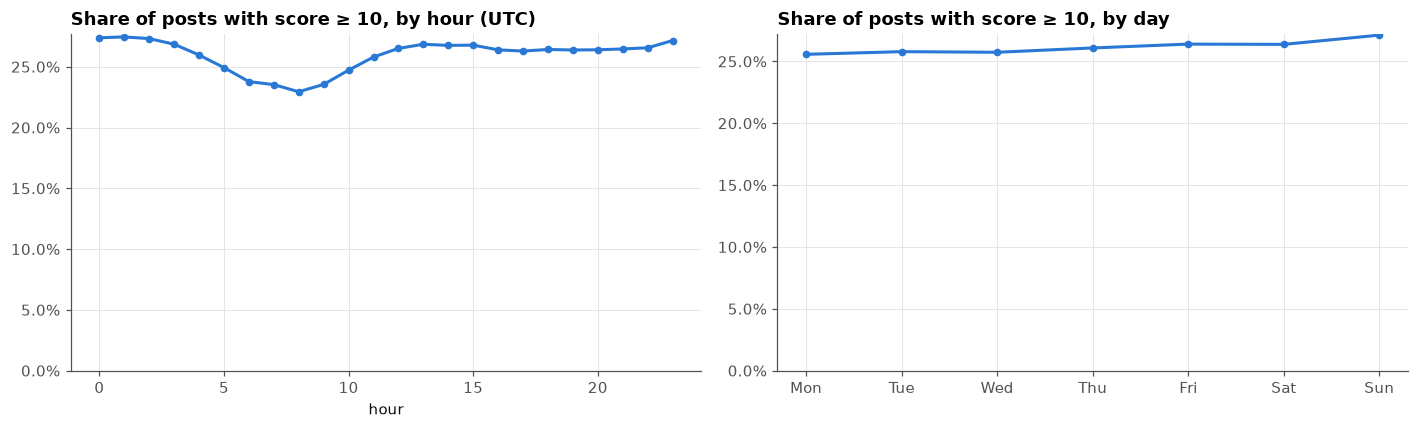

In [21]:
by_hour = q("""
SELECT hour(created_at) AS hour, count(*) AS posts, median(score) AS median_score,
       avg((score >= 10)::INT) AS frac_score_ge_10
FROM subs GROUP BY 1 ORDER BY 1
""")
by_dow = q("""
SELECT isodow(created_at) AS dow, dayname(created_at) AS day, count(*) AS posts,
       median(score) AS median_score, avg((score >= 10)::INT) AS frac_score_ge_10
FROM subs GROUP BY 1, 2 ORDER BY 1
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(by_hour.hour, by_hour.frac_score_ge_10, color=BLUE, linewidth=2, marker="o", markersize=4)
axes[0].set_title("Share of posts with score ≥ 10, by hour (UTC)"); axes[0].set_xlabel("hour")
axes[1].plot(by_dow.day.str[:3], by_dow.frac_score_ge_10, color=BLUE, linewidth=2, marker="o", markersize=4)
axes[1].set_title("Share of posts with score ≥ 10, by day")
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.set_ylim(bottom=0)
plt.tight_layout()
by_dow

## 7. Post type

The type comes from `url` and `selftext`: self (text) post, image, video, gallery, or external link.

In [22]:
TYPE_SQL = """
CASE
  WHEN url IS NULL OR url = '' THEN 'no url'
  WHEN url LIKE '%reddit.com/r/%/comments/%' OR url LIKE '%reddit.com/r/%/s/%' THEN 'self'
  WHEN url LIKE '%i.redd.it%' OR regexp_matches(lower(url), '\\.(jpg|jpeg|png|gif|webp)$') OR url LIKE '%imgur.com%' THEN 'image'
  WHEN url LIKE '%v.redd.it%' OR url LIKE '%youtube.com%' OR url LIKE '%youtu.be%' THEN 'video'
  WHEN url LIKE '%reddit.com/gallery/%' THEN 'gallery'
  ELSE 'external link'
END
"""
by_type = q(f"""
SELECT {TYPE_SQL} AS post_type, count(*) AS posts, count(*) / sum(count(*)) OVER () AS share,
       median(score) AS median_score, quantile_cont(score, 0.9) AS p90_score,
       median(num_comments) AS median_comments, avg((score >= 10)::INT) AS frac_score_ge_10
FROM subs GROUP BY 1 ORDER BY posts DESC
""")
by_type

,post_type,posts,share,median_score,p90_score,median_comments,frac_score_ge_10
0,self,16109842,0.453,1.000,13.000,2.000,0.129
1,image,8874892,0.249,6.000,192.000,3.000,0.447
2,gallery,4224686,0.119,5.000,127.000,3.000,0.408
3,external link,3240980,0.091,1.000,23.000,0.000,0.139
4,video,3139197,0.088,2.000,127.000,1.000,0.345
5,no url,7,0.000,1.000,1.000,0.000,0.000


In [23]:
top_domains = q("""
SELECT regexp_extract(url, '^https?://(?:www\\.)?([^/]+)', 1) AS domain,
       count(*) AS posts, median(score) AS median_score
FROM subs GROUP BY 1 ORDER BY posts DESC LIMIT 20
""")
top_domains

,domain,posts,median_score
0,reddit.com,20400729,1.000
1,i.redd.it,8789308,6.000
2,v.redd.it,2093303,7.000
3,youtube.com,573013,1.000
4,youtu.be,458400,1.000
5,,426820,1.000
6,theguardian.com,58108,1.000
7,bbc.com,41334,1.000
8,x.com,39661,2.000
9,open.spotify.com,38654,1.000


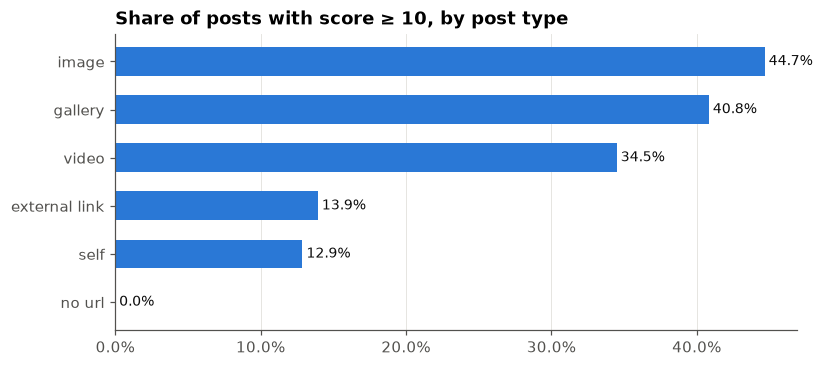

In [24]:
d = by_type.sort_values("frac_score_ge_10")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(d.post_type, d.frac_score_ge_10, color=BLUE, height=0.6)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for y, v in enumerate(d.frac_score_ge_10):
    ax.text(v, y, f" {v:.1%}", va="center", color=INK, fontsize=9)
ax.set_title("Share of posts with score ≥ 10, by post type"); ax.grid(axis="y", visible=False)

## 8. Text features (2M-post sample)

In [25]:
text = q("""
SELECT score, num_comments, title_length,
       length(coalesce(selftext, '')) AS selftext_length,
       contains(title, '?')                                AS title_has_question,
       regexp_matches(title, '\\d')                      AS title_has_number,
       title = upper(title) AND regexp_matches(title, '[A-Z]') AS title_all_caps,
       len(string_split(title, ' '))                       AS title_words
FROM subs_sample
""")
text.describe(percentiles=[0.5, 0.9, 0.99]).T

,count,mean,std,min,50%,90%,99%,max
score,"2,000,000.000",62.617,721.913,0.000,2.000,65.000,976.000,"135,667.000"
num_comments,"2,000,000.000",10.930,79.231,0.000,2.000,22.000,134.000,"24,584.000"
title_length,"2,000,000.000",47.314,39.378,1.000,37.000,90.000,218.000,300.000
selftext_length,"2,000,000.000",336.119,985.806,0.000,83.000,824.000,"3,553.000","41,675.000"
title_words,"2,000,000.000",8.337,6.948,1.000,7.000,16.000,38.000,228.000


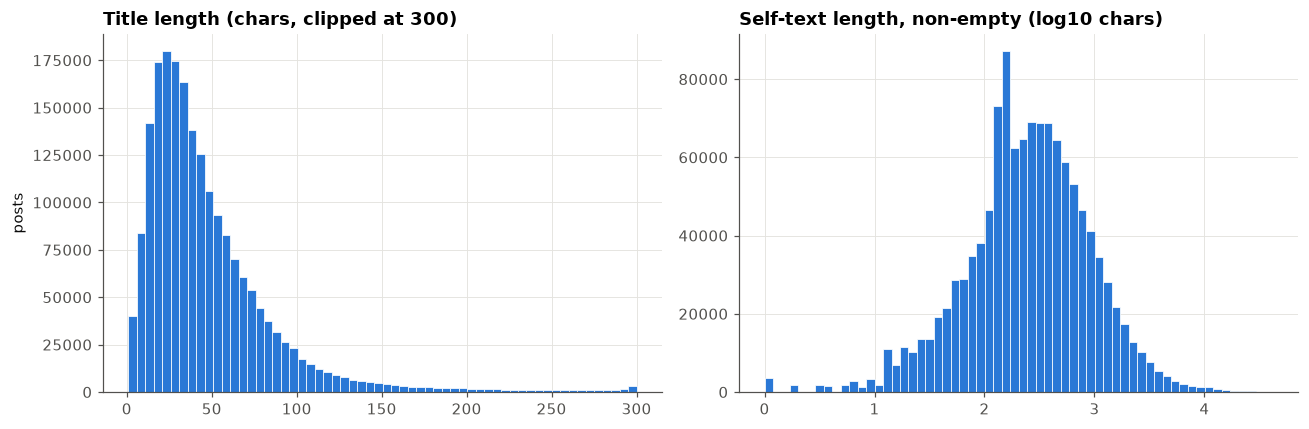

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(text.title_length.clip(upper=300), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_title("Title length (chars, clipped at 300)"); axes[0].set_ylabel("posts")
sl = text.selftext_length[text.selftext_length > 0]
axes[1].hist(np.log10(sl), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[1].set_title("Self-text length, non-empty (log10 chars)")
plt.tight_layout()

,posts,median_score,frac_score_ge_10
title_len_bin,,,
"(0.999, 13.0]",206732,2.000,0.273
"(13.0, 19.0]",197645,2.000,0.283
"(19.0, 25.0]",215762,2.000,0.273
"(25.0, 31.0]",207560,2.000,0.267
"(31.0, 37.0]",188273,2.000,0.255
"(37.0, 45.0]",206563,2.000,0.252
"(45.0, 54.0]",181612,2.000,0.258
"(54.0, 67.0]",195935,1.000,0.251
"(67.0, 90.0]",202951,1.000,0.249


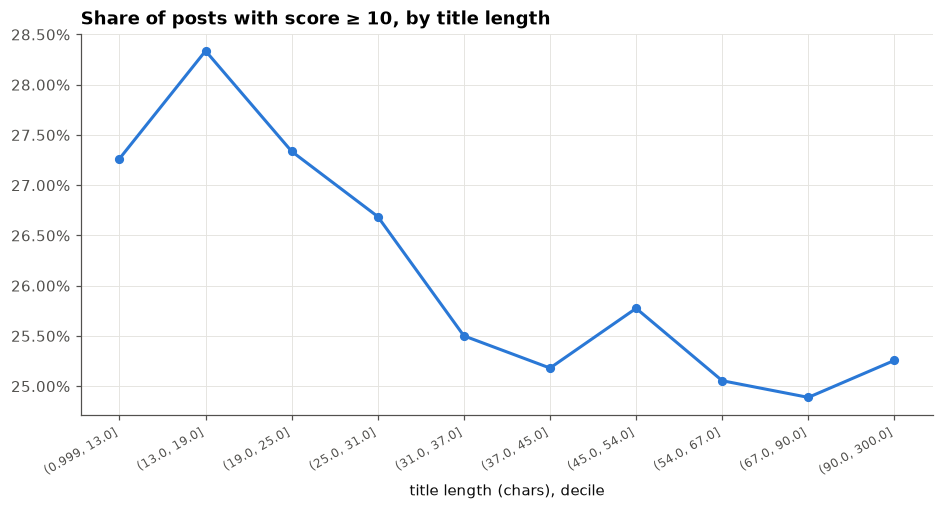

In [27]:
# Median score and share with score >= 10 in title-length deciles
text["title_len_bin"] = pd.qcut(text.title_length, 10, duplicates="drop")
g = text.groupby("title_len_bin", observed=True).agg(
    posts=("score", "size"), median_score=("score", "median"),
    frac_score_ge_10=("score", lambda x: (x >= 10).mean()))
fig, ax = plt.subplots()
ax.plot(range(len(g)), g.frac_score_ge_10, color=BLUE, linewidth=2, marker="o", markersize=5)
ax.set_xticks(range(len(g)), [str(i) for i in g.index], rotation=30, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("title length (chars), decile"); ax.set_title("Share of posts with score ≥ 10, by title length")
g

In [28]:
rows = []
for f in ["title_has_question", "title_has_number", "title_all_caps"]:
    for val, grp in text.groupby(f):
        rows.append({"feature": f, "value": val, "posts": len(grp),
                     "median_score": grp.score.median(), "frac_score_ge_10": (grp.score >= 10).mean()})
pd.DataFrame(rows)

,feature,value,posts,median_score,frac_score_ge_10
0,title_has_question,False,1561968,2.000,0.275
1,title_has_question,True,438032,2.000,0.213
2,title_has_number,False,1529972,2.000,0.279
3,title_has_number,True,470028,1.000,0.203
4,title_all_caps,False,1963355,2.000,0.262
5,title_all_caps,True,36645,1.000,0.249


In [29]:
del text

## 9. Flair and authors

In [30]:
q("""
SELECT link_flair_text IS NOT NULL AS has_flair, count(*) AS posts,
       median(score) AS median_score, avg((score >= 10)::INT) AS frac_score_ge_10
FROM subs GROUP BY 1 ORDER BY 1
""")

,has_flair,posts,median_score,frac_score_ge_10
0,False,16737638,1.000,0.216
1,True,18851966,2.000,0.301


In [31]:
authors = q("""
SELECT author, count(*) AS posts, count(DISTINCT subreddit) AS subreddits, median(score) AS median_score
FROM subs GROUP BY author
""")
print(authors.posts.describe(percentiles=[0.5, 0.9, 0.99, 0.999]))
authors.sort_values("posts", ascending=False).head(15)

count   11,201,292.000
mean             3.177
std            105.802
min              1.000
50%              1.000
90%              5.000
99%             25.000
99.9%          111.000
max        178,709.000
Name: posts, dtype: float64


,author,posts,subreddits,median_score
129276,chess-quiz-plus,178709,1,1.000
5572272,lss_web_1444,154786,4,1.000
10638322,AutoModerator,112791,12230,1.000
7921213,AutoNewsAdmin,108527,34,1.000
2355351,AutoNewspaperAdmin,104107,1,1.000
8346528,hatchcats-game,84554,1,1.000
95071,asteroid-app,83407,1,1.000
5532087,GameProfessional,48250,20,1.000
8370015,playwright_non_admin,43246,1,1.000
61,rrmdp,38215,2,1.000


Text(0.0, 1.0, 'Posts per author')

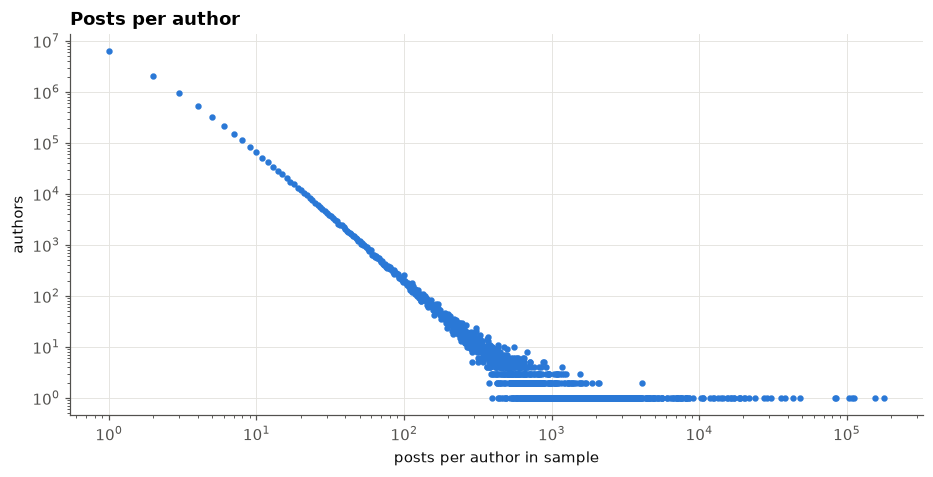

In [32]:
# Authors with many posts in many subreddits are often spam or bot accounts
fig, ax = plt.subplots()
vc = authors.posts.value_counts().sort_index()
ax.scatter(vc.index, vc.values, s=10, color=BLUE)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("posts per author in sample"); ax.set_ylabel("authors")
ax.set_title("Posts per author")

## 10. Possible "success" labels

Some candidate definitions and their class balance. A label relative to the subreddit avoids a model that
only learns "big subreddits get big scores".

In [33]:
labels = q("""
WITH base AS (
  SELECT *, percent_rank() OVER (PARTITION BY subreddit ORDER BY score) AS sub_pct,
         count(*) OVER (PARTITION BY subreddit) AS sub_n
  FROM subs
)
SELECT count(*)                                         AS posts,
       avg((score >= 10)::INT)                          AS score_ge_10,
       avg((score >= 100)::INT)                         AS score_ge_100,
       avg((num_comments >= 10)::INT)                   AS comments_ge_10,
       avg((sub_pct >= 0.9)::INT) FILTER (sub_n >= 50)  AS top10pct_in_subreddit,
       count(*) FILTER (sub_n >= 50)                    AS posts_in_subs_ge_50
FROM base
""")
labels.T.rename(columns={0: "value"})

,value
posts,"35,589,604.000"
score_ge_10,0.261
score_ge_100,0.076
comments_ge_10,0.209
top10pct_in_subreddit,0.087
posts_in_subs_ge_50,"32,535,321.000"


## Summary

Fill in after you run the notebook. Questions to answer:

- How heavy are the tails of `score` and `num_comments`? A log transform or a classification label is probably necessary.
- How much does the subreddit explain? Do we normalize the label in each subreddit?
- Which simple features (time, post type, title length, flair) show a signal?
- Is the archival-time `score` mature enough to use as a target, or do we use an older month?